In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


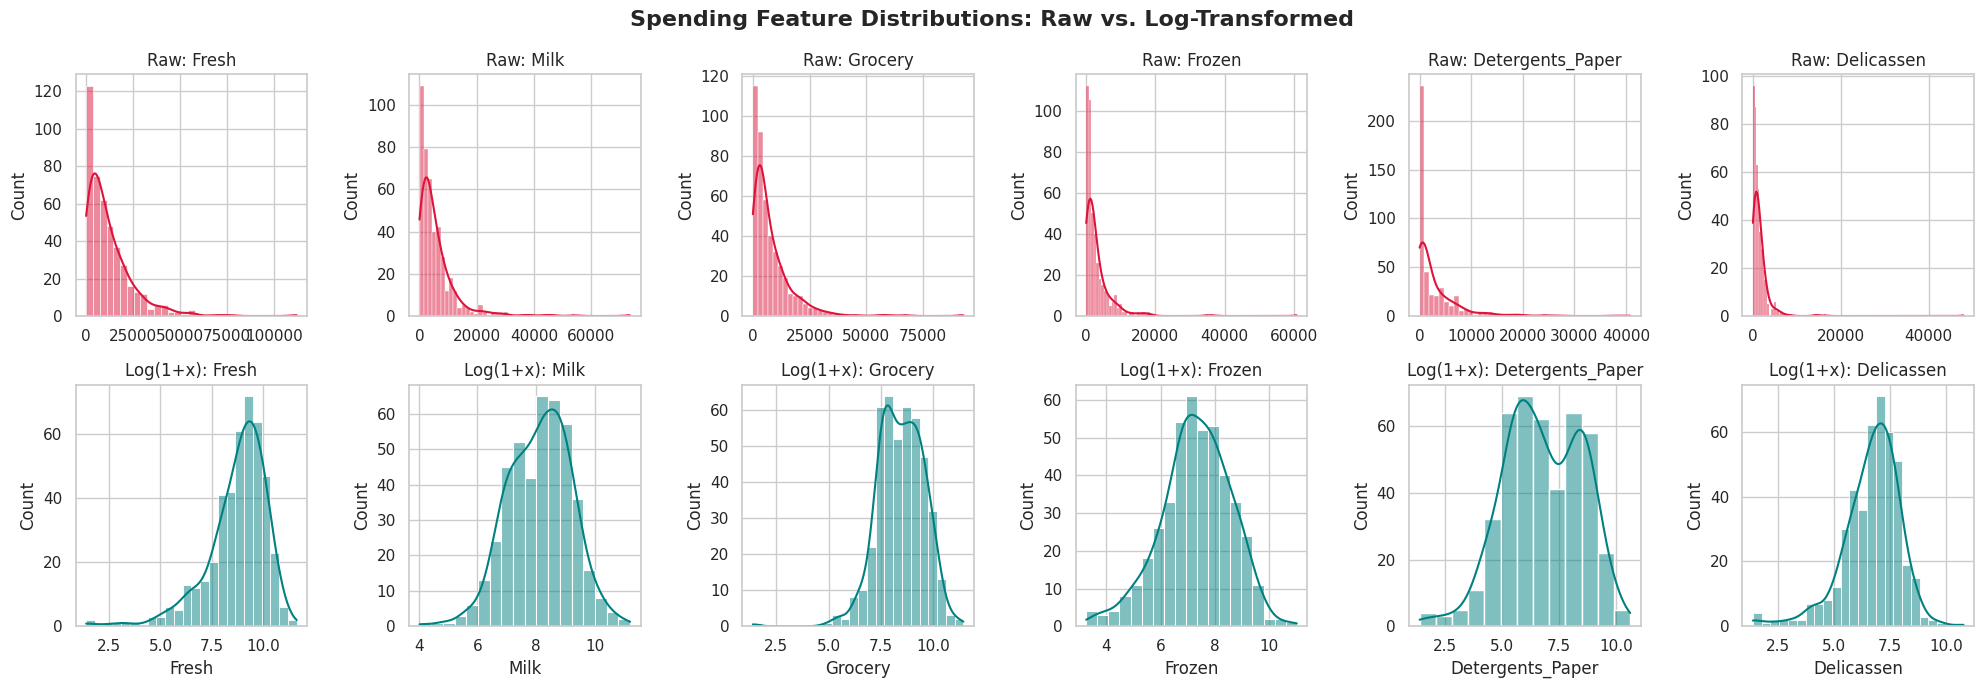

In [4]:

# Set aesthetic styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Load Dataset
df = pd.read_csv("Wholesale customers data.csv")

# Continuous spending columns
spending_cols = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen",
]

# -------------------------------------------------------------------------
# VISUALIZATION 1: Raw vs Log-Transformed Distributions
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle(
    "Spending Feature Distributions: Raw vs. Log-Transformed",
    fontsize=16,
    fontweight="bold",
)

for i, col in enumerate(spending_cols):
    # Raw Distribution
    sns.histplot(df[col], kde=True, ax=axes[0, i], color="crimson")
    axes[0, i].set_title(f"Raw: {col}")
    axes[0, i].set_xlabel("")

    # Log-Transformed Distribution
    sns.histplot(
        np.log1p(df[col]), kde=True, ax=axes[1, i], color="teal"
    )
    axes[1, i].set_title(f"Log(1+x): {col}")

plt.tight_layout()
plt.show()


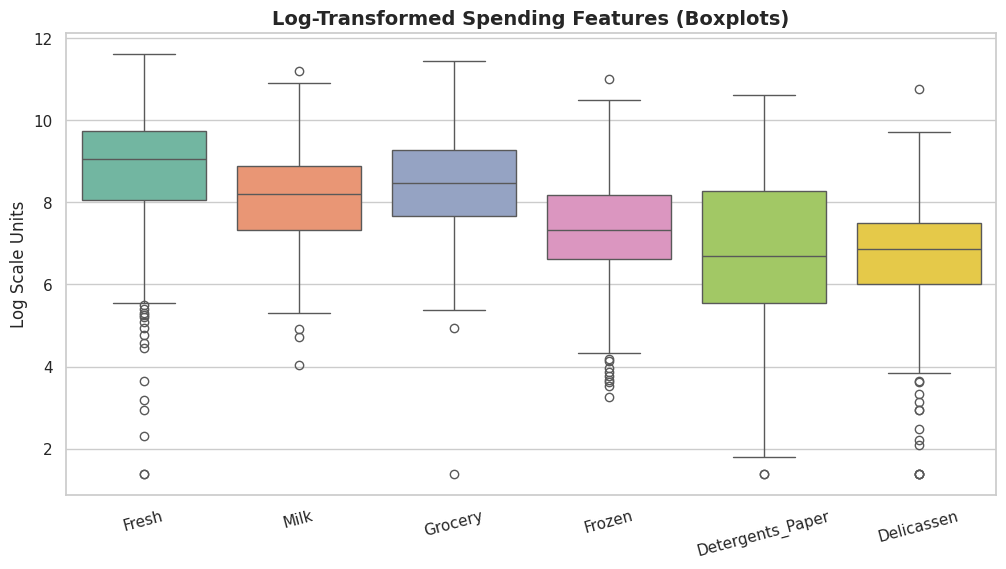

In [5]:

# -------------------------------------------------------------------------
# VISUALIZATION 2: Outlier Diagnostic Boxplots
# -------------------------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(data=np.log1p(df[spending_cols]), palette="Set2")
plt.title(
    "Log-Transformed Spending Features (Boxplots)",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Log Scale Units")
plt.xticks(rotation=15)
plt.show()


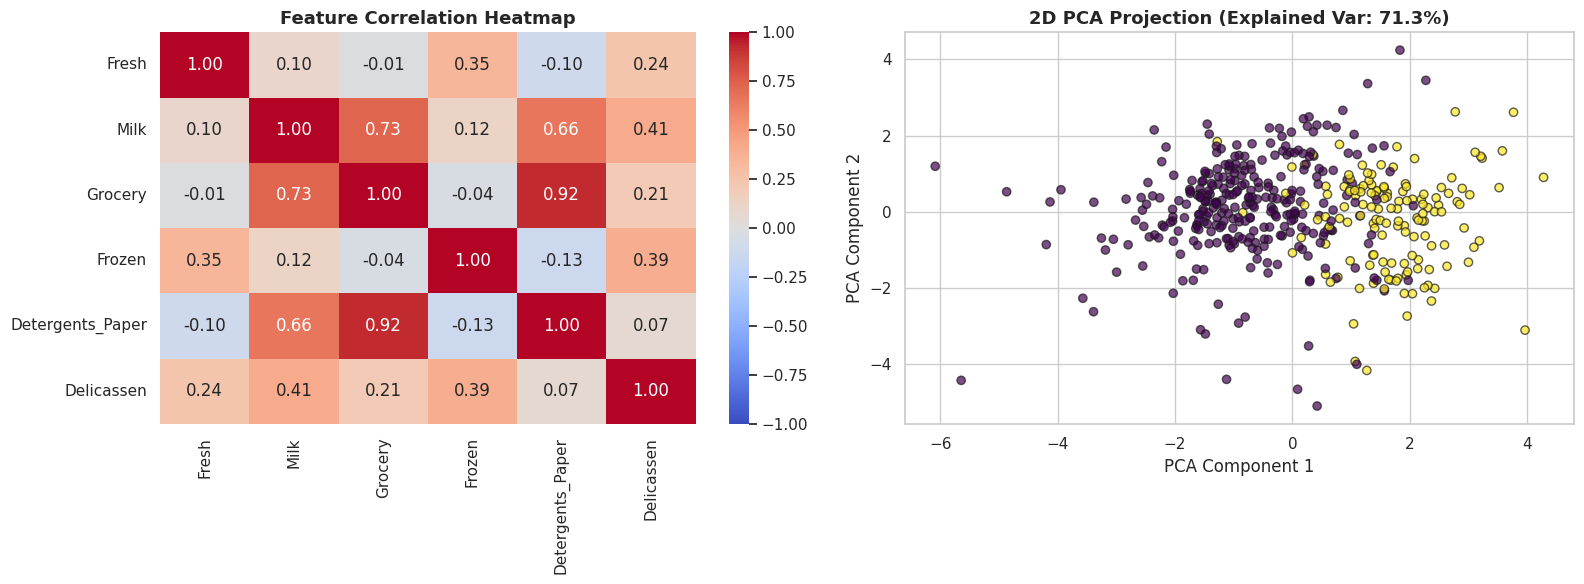

In [6]:

# -------------------------------------------------------------------------
# VISUALIZATION 3: Correlation Heatmap & PCA 2D Spatial Scatter
# -------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Correlation Matrix
corr = df[spending_cols].corr()
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, ax=ax1, vmin=-1, vmax=1
)
ax1.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")

# Subplot B: PCA 2D Spatial Layout (Density Check)
X_scaled = StandardScaler().fit_transform(np.log1p(df[spending_cols]))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ax2.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Channel"],
    cmap="viridis",
    alpha=0.7,
    edgecolor="k",
)
ax2.set_title(
    f"2D PCA Projection (Explained Var: {sum(pca.explained_variance_ratio_):.1%})",
    fontsize=13,
    fontweight="bold",
)
ax2.set_xlabel("PCA Component 1")
ax2.set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()


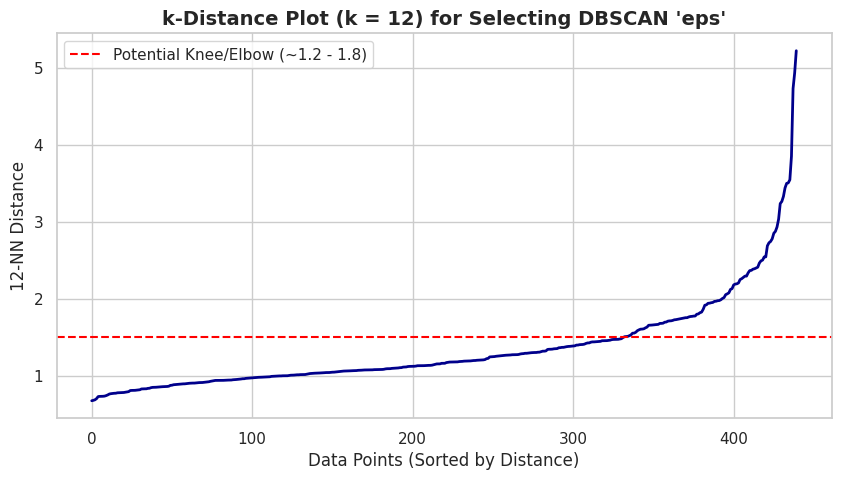

In [7]:

# -------------------------------------------------------------------------
# VISUALIZATION 4: k-Distance Plot for Optimal 'eps' Determination
# -------------------------------------------------------------------------
# Rule of thumb for min_samples in DBSCAN: k = 2 * number_of_features = 2 * 6 = 12
k = 2 * len(spending_cols)

nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Sort distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color="darkblue", linewidth=2)
plt.title(
    f"k-Distance Plot (k = {k}) for Selecting DBSCAN 'eps'",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Data Points (Sorted by Distance)")
plt.ylabel(f"{k}-NN Distance")
plt.axhline(
    y=1.5, color="red", linestyle="--", label="Potential Knee/Elbow (~1.2 - 1.8)"
)
plt.legend()
plt.show()